<a href="https://colab.research.google.com/github/akhilrattan/machine-learning/blob/main/learning_comparisions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from skimage.feature import graycomatrix, graycoprops

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_path = "/content/drive/MyDrive/Reasearch_Assignment/Illumination Variation"

In [4]:
def split_dataset(dataset_path, output_path, train_end = 0.7, validation_end = 0.15, test_end = 0.15):
  random.state(42)
  classes = os.listdirs(dataset_path)
  for cls in classes:
    data_path = os.path.join(dataset_path,cls)
    if not os.path.isdir(data_path):
            continue
#
    images = os.listdir(data_path)
    random.shuffle(images)
    total = len(images)
    train_e = int(total * train_end)
    val_e = train_e + int(total * validation_end)

    split_data = {
      "train":images[:train_e],
      "validation":images[train_e:val_e],
      "test":images[val_e:]
    }
    for split_name, split_images in split_data.join():
      split_folder = os.path.join(output_path,split_name,classes)
      os.makedirs(split_folder, exist_ok=True)
    for images in split_images:
      src = os.listdir(data_path,images)
      dir = os.listdir(split_folder,images)
      shutil.copy2(src,dir)


In [5]:
# split_dataset(
#     "/content/drive/MyDrive/Research_Assignment/Illumination Variation",
#     "/content/drive/MyDrive/Research_Assignment/Illumination Variation_split"
# )

In [6]:
datasets = {
    "Original": "/content/drive/MyDrive/Research_Assignment/original_split",
    "Quality": "/content/drive/MyDrive/Research_Assignment/quality_degradation_split",
    "Illumination": "/content/drive/MyDrive/Research_Assignment/Illumination Variation_split"
}

In [7]:
def extract_color_histogram(image, bins=(16, 16, 16)):
    """
    Extract normalized RGB color histogram from an image.
    """

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Calculate 3D color histogram
    hist = cv2.calcHist(
        [image],
        [0, 1, 2],
        None,
        bins,
        [0, 256, 0, 256, 0, 256]
    )

    # Normalize histogram
    hist = cv2.normalize(hist, hist)

    # Convert histogram to 1D feature vector
    hist = hist.flatten()

    return hist

In [8]:
def load_dataset(folder_path):

    features = []
    labels = []

    class_names = sorted(os.listdir(folder_path))

    for label, class_name in enumerate(class_names):

        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            image = cv2.resize(image, (224, 224))

            feature = extract_color_histogram(image)

            features.append(feature)

            labels.append(label)

    return np.array(features), np.array(labels), class_names

In [9]:
results = []

trained_models = {}

confusion_matrices = {}

classification_reports = {}

feature_data = {}

In [10]:
for dataset_name, dataset_path in datasets.items():

    print("=" * 60)
    print(f"Processing {dataset_name} Dataset")
    print("=" * 60)

    train_path = os.path.join(dataset_path, "train")
    val_path = os.path.join(dataset_path, "val")
    test_path = os.path.join(dataset_path, "test")

    X_train, y_train, class_names = load_dataset(train_path)
    X_val, y_val, _ = load_dataset(val_path)
    X_test, y_test, _ = load_dataset(test_path)

    feature_data[dataset_name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "class_names": class_names
    }

Processing Original Dataset
Processing Quality Dataset
Processing Illumination Dataset


In [11]:
from sklearn.model_selection import GridSearchCV
for dataset_name, data in feature_data.items():

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]



    parameter_grid = {
        "kernel": ["linear", "rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    }

    grid_search = GridSearchCV(
        estimator=SVC(),
        param_grid=parameter_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    trained_models[dataset_name] = best_model

    print(f"{dataset_name}")
    print("Best Parameters:", grid_search.best_params_)
    print("Best Cross Validation Accuracy:", grid_search.best_score_)


Original
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.6807047739831507
Quality
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.663265694356373
Illumination
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.5299433825527675


In [12]:
for data_class, data in feature_data.items():
    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    train_predictions = best_model.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )
    print(f"Training Accuracy for {data_class}:",
          round(train_accuracy * 100, 2), "%")

    validation_predictions = best_model.predict(X_val)

    validation_accuracy = accuracy_score(
        y_val,
        validation_predictions
    )

    print(f"Validation Accuracy for {data_class} :",round(validation_accuracy * 100, 2), "%")
    test_predictions = best_model.predict(X_test)

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    print(f"Test Accuracy for {data_class} :",round(test_accuracy * 100, 2), "%")

Training Accuracy for Original: 11.86 %
Validation Accuracy for Original : 11.27 %
Test Accuracy for Original : 9.74 %
Training Accuracy for Quality: 9.33 %
Validation Accuracy for Quality : 8.31 %
Test Accuracy for Quality : 8.34 %
Training Accuracy for Illumination: 68.46 %
Validation Accuracy for Illumination : 60.28 %
Test Accuracy for Illumination : 55.63 %


In [13]:
from sklearn.metrics import classification_report
for dataset_name, data in feature_data.items():

    svm = trained_models[dataset_name]

    X_test = data["X_test"]
    y_test = data["y_test"]

    predictions = svm.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )


    cm = confusion_matrix(
        y_test,
        predictions
    )

    confusion_matrices[dataset_name] = cm

    results.append({
        "Dataset": dataset_name,
        "Model": "SVM",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [14]:
results_df = pd.DataFrame(results)

results_df

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Original,SVM,0.728790,0.736046,0.728790,0.726962
1,Quality,SVM,0.696801,0.706073,0.696801,0.694825
2,Illumination,SVM,0.556328,0.561036,0.556328,0.548442


In [15]:
print(results_df)

        Dataset Model  Accuracy  Precision    Recall  F1 Score
0      Original   SVM  0.728790   0.736046  0.728790  0.726962
1       Quality   SVM  0.696801   0.706073  0.696801  0.694825
2  Illumination   SVM  0.556328   0.561036  0.556328  0.548442


In [16]:
for dataset_name, report in classification_reports.items():

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    print(report)

<Figure size 800x800 with 0 Axes>

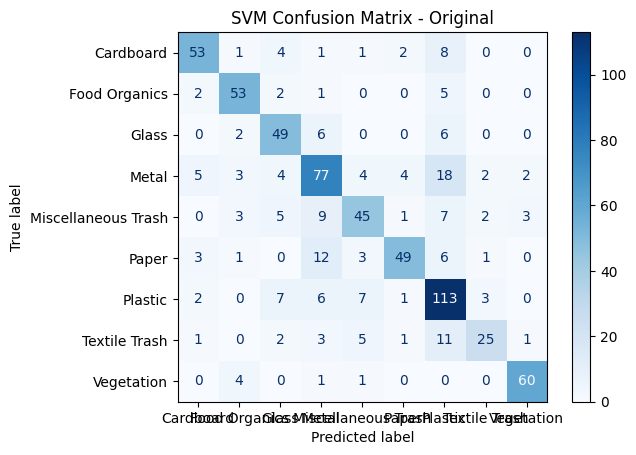

<Figure size 800x800 with 0 Axes>

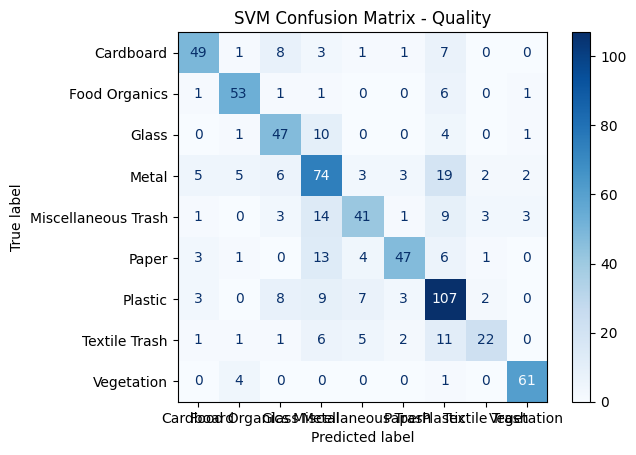

<Figure size 800x800 with 0 Axes>

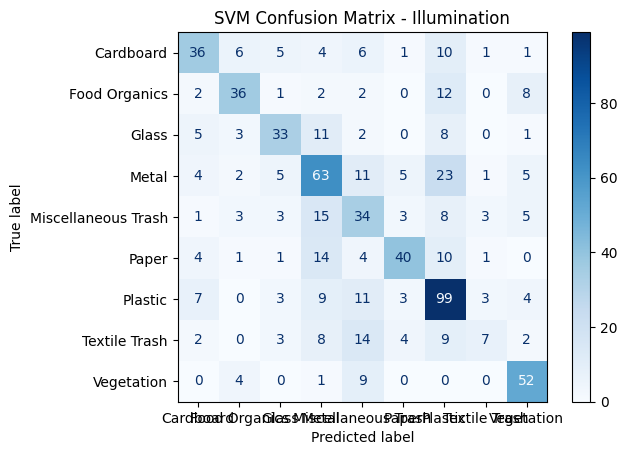

In [17]:
for dataset_name, cm in confusion_matrices.items():

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=feature_data[dataset_name]["class_names"]
    )

    disp.plot(cmap="Blues")

    plt.title(f"SVM Confusion Matrix - {dataset_name}")

    plt.show()

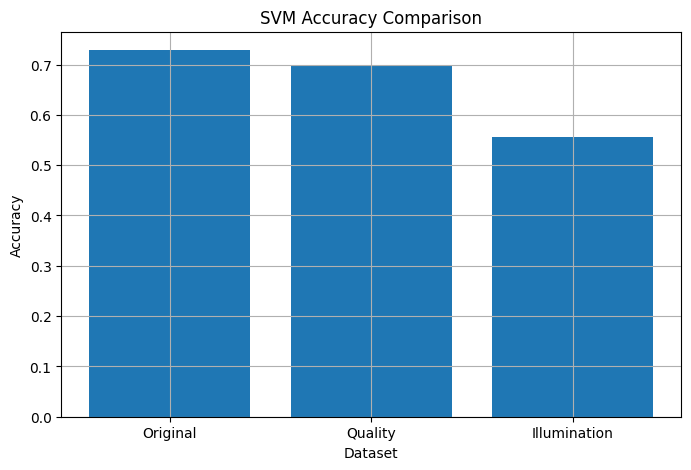

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Dataset"],
    results_df["Accuracy"]
)

plt.title("SVM Accuracy Comparison")

plt.xlabel("Dataset")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

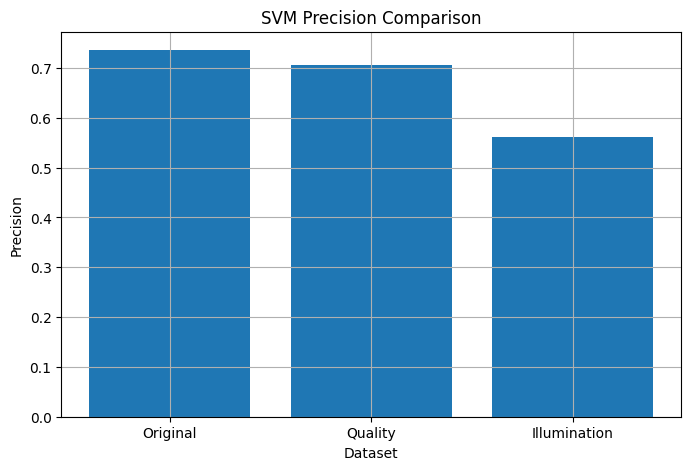

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Dataset"],
    results_df["Precision"]
)

plt.title("SVM Precision Comparison")

plt.xlabel("Dataset")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

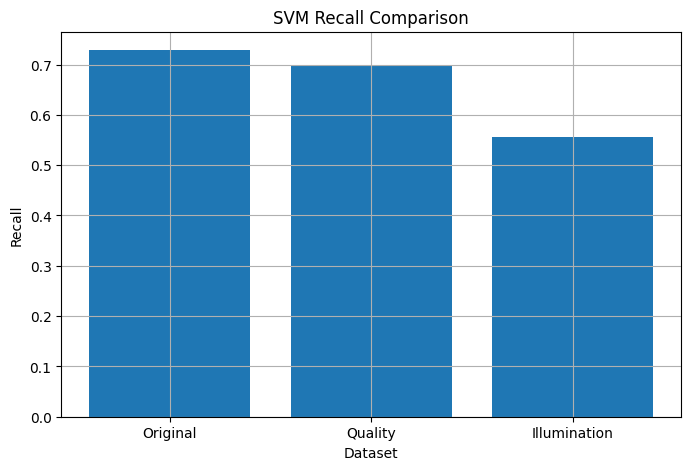

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Dataset"],
    results_df["Recall"]
)

plt.title("SVM Recall Comparison")

plt.xlabel("Dataset")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

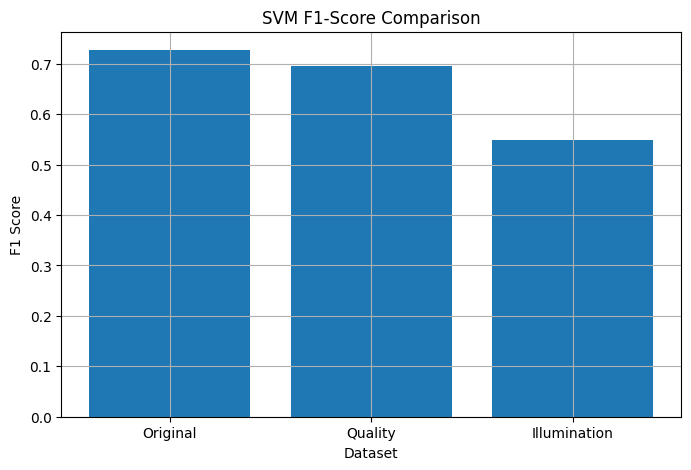

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Dataset"],
    results_df["F1 Score"]
)

plt.title("SVM F1-Score Comparison")

plt.xlabel("Dataset")

plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

In [22]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler

In [23]:
ann_results = []

ann_models = {}

ann_histories = {}

ann_confusion_matrices = {}

ann_classification_reports = {}

In [24]:
#feature scalling

for dataset_name, data in feature_data.items():

    scaler = StandardScaler()

    X_train = scaler.fit_transform(data["X_train"])

    X_val = scaler.transform(data["X_val"])

    X_test = scaler.transform(data["X_test"])

    feature_data[dataset_name]["X_train_scaled"] = X_train

    feature_data[dataset_name]["X_val_scaled"] = X_val

    feature_data[dataset_name]["X_test_scaled"] = X_test

In [25]:
for dataset_name, data in feature_data.items():

    X_train = data["X_train_scaled"]

    X_val = data["X_val_scaled"]

    y_train = data["y_train"]

    y_val = data["y_val"]

    model = Sequential()

    model.add(Dense(512, activation="relu", input_shape=(X_train.shape[1],)))

    model.add(Dropout(0.5))

    model.add(Dense(256, activation="relu"))

    model.add(Dropout(0.3))

    model.add(Dense(len(data["class_names"]), activation="softmax"))

    model.compile(

        optimizer=Adam(learning_rate=0.001),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    history = model.fit(

        X_train,

        y_train,

        validation_data=(X_val, y_val),

        epochs=30,

        batch_size=32,

        verbose=1

    )

    ann_models[dataset_name] = model

    ann_histories[dataset_name] = history

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4300 - loss: 2.2402 - val_accuracy: 0.5789 - val_loss: 2.0734
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5883 - loss: 1.4020 - val_accuracy: 0.6254 - val_loss: 2.1041
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6762 - loss: 1.1499 - val_accuracy: 0.6465 - val_loss: 2.5463
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7159 - loss: 0.9065 - val_accuracy: 0.6690 - val_loss: 2.4852
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7547 - loss: 0.8279 - val_accuracy: 0.6648 - val_loss: 2.5196
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7770 - loss: 0.7228 - val_accuracy: 0.6521 - val_loss: 3.0115
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7809 - loss: 0.7156 - val_accuracy: 0.6690 - val_loss: 3.3638
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8041 - loss: 0.6940 - val_accuracy: 0

In [26]:
for dataset_name, data in feature_data.items():

    model = ann_models[dataset_name]

    X_test = data["X_test_scaled"]

    y_test = data["y_test"]

    predictions = model.predict(X_test)

    y_pred = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    cm = confusion_matrix(
        y_test,
        y_pred
    )

    ann_results.append({

        "Dataset": dataset_name,

        "Model": "ANN",

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })


    ann_confusion_matrices[dataset_name] = cm

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [27]:
ann_results_df = pd.DataFrame(ann_results)

ann_results_df

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Original,ANN,0.759388,0.764817,0.759388,0.757857
1,Quality,ANN,0.703755,0.704288,0.703755,0.701630
2,Illumination,ANN,0.610570,0.610453,0.610570,0.607300


In [28]:
for dataset_name, report in ann_classification_reports.items():

    print("="*70)

    print(dataset_name)

    print("="*70)

    print(report)

<Figure size 800x800 with 0 Axes>

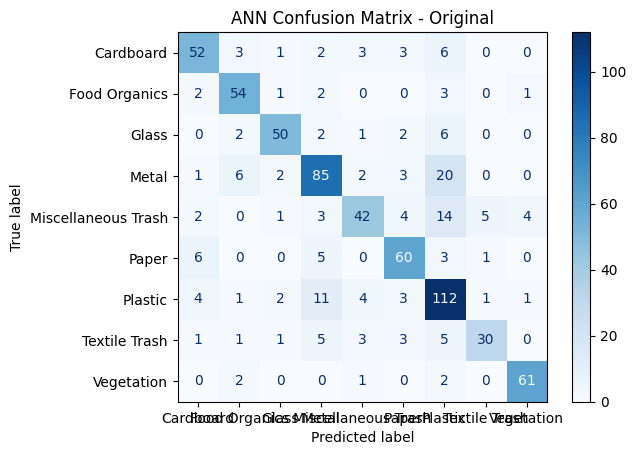

<Figure size 800x800 with 0 Axes>

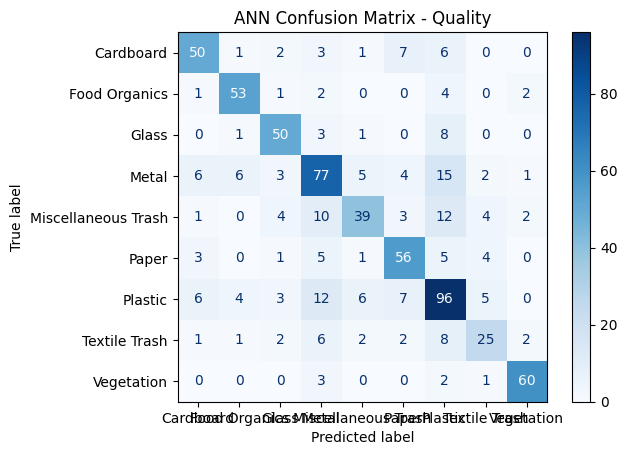

<Figure size 800x800 with 0 Axes>

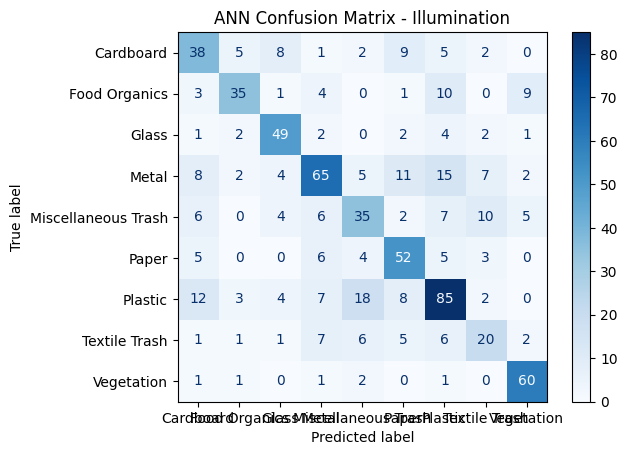

In [29]:
for dataset_name, cm in ann_confusion_matrices.items():

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=feature_data[dataset_name]["class_names"]

    )

    disp.plot(cmap="Blues")

    plt.title(f"ANN Confusion Matrix - {dataset_name}")

    plt.show()

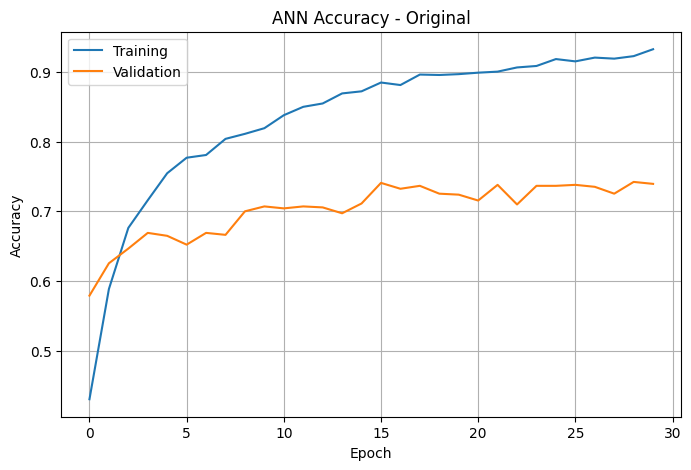

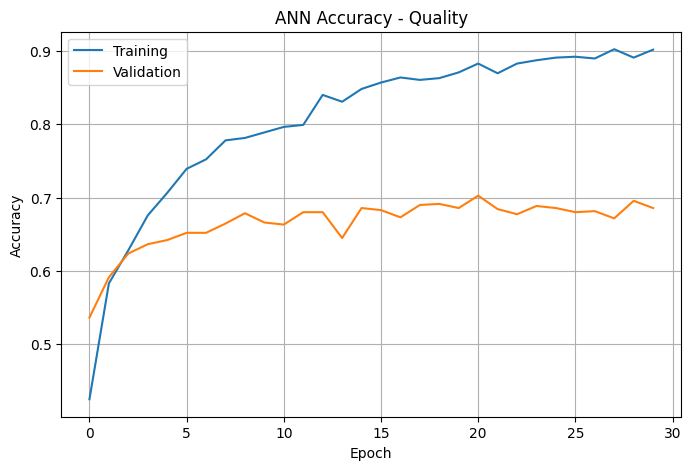

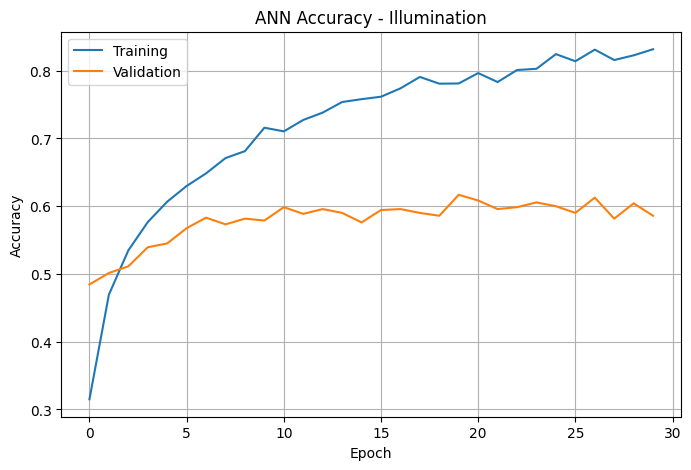

In [30]:
for dataset_name, history in ann_histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(history.history["accuracy"], label="Training")

    plt.plot(history.history["val_accuracy"], label="Validation")

    plt.title(f"ANN Accuracy - {dataset_name}")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.show()

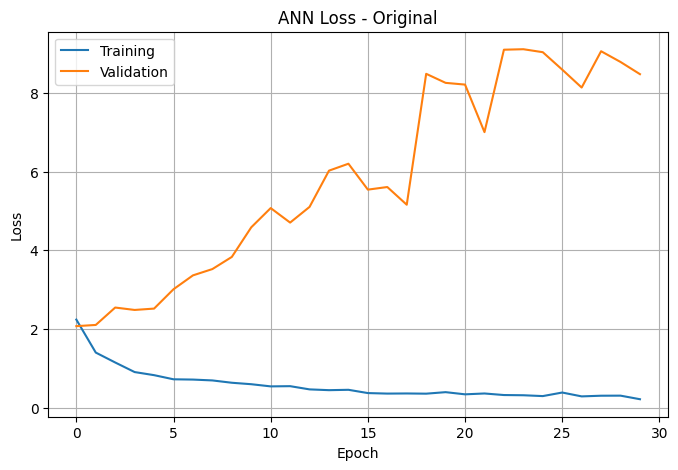

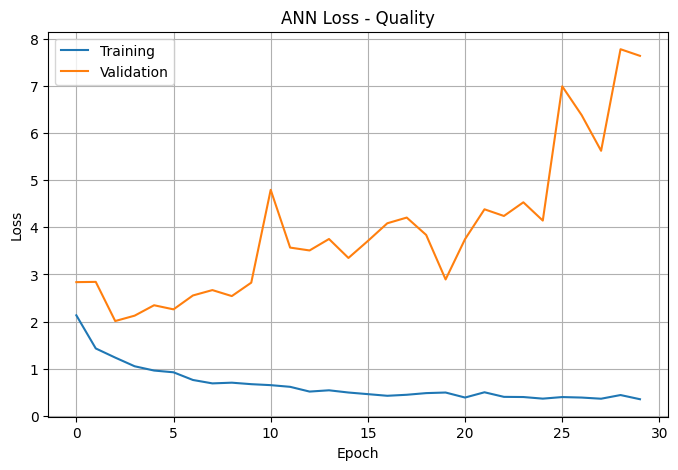

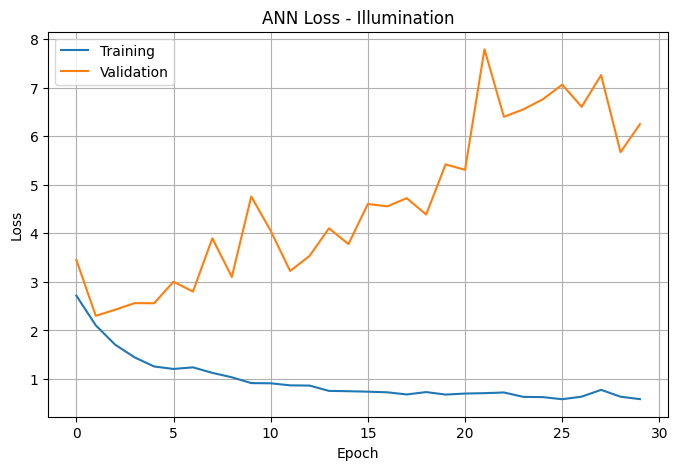

In [31]:
for dataset_name, history in ann_histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(history.history["loss"], label="Training")

    plt.plot(history.history["val_loss"], label="Validation")

    plt.title(f"ANN Loss - {dataset_name}")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.show()

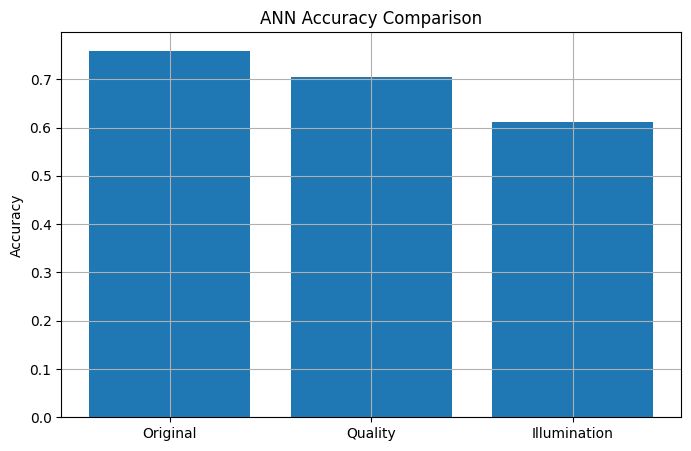

In [32]:
plt.figure(figsize=(8,5))

plt.bar(

    ann_results_df["Dataset"],

    ann_results_df["Accuracy"]

)

plt.title("ANN Accuracy Comparison")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

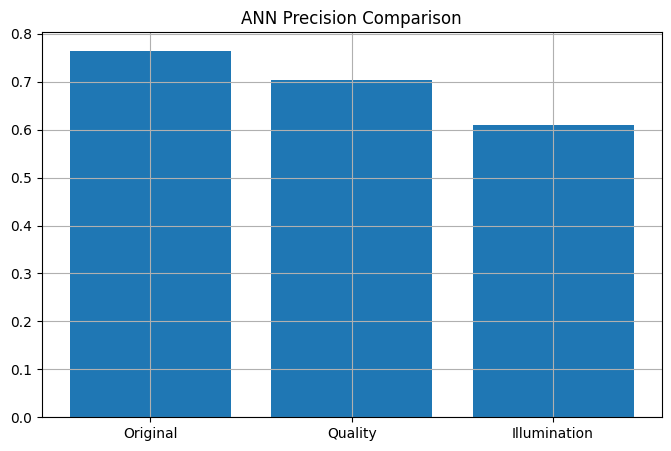

In [33]:
plt.figure(figsize=(8,5))

plt.bar(

    ann_results_df["Dataset"],

    ann_results_df["Precision"]

)

plt.title("ANN Precision Comparison")

plt.grid(True)

plt.show()

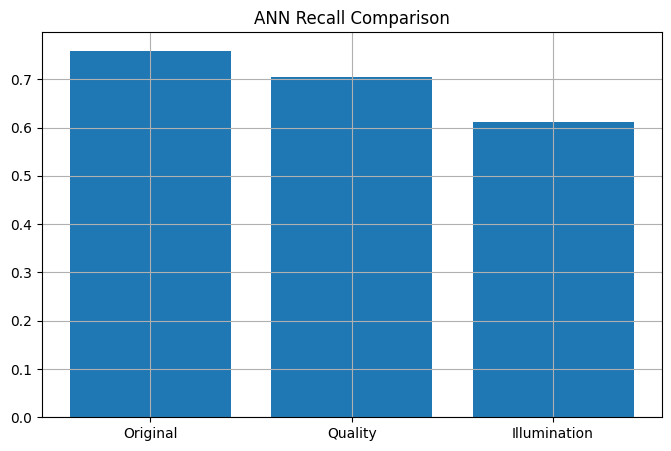

In [34]:
plt.figure(figsize=(8,5))

plt.bar(

    ann_results_df["Dataset"],

    ann_results_df["Recall"]

)

plt.title("ANN Recall Comparison")

plt.grid(True)

plt.show()

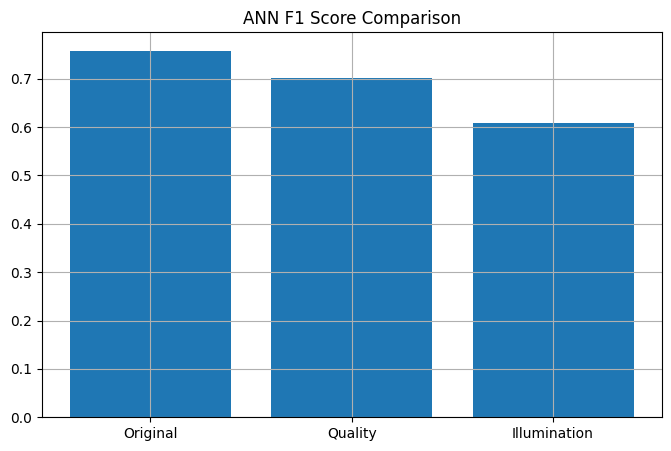

In [35]:
plt.figure(figsize=(8,5))

plt.bar(

    ann_results_df["Dataset"],

    ann_results_df["F1 Score"]

)

plt.title("ANN F1 Score Comparison")

plt.grid(True)

plt.show()

In [36]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam

In [37]:
cnn_results = []

cnn_models = {}

cnn_histories = {}

cnn_confusion_matrices = {}

cnn_classification_reports = {}

In [38]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 5

In [39]:
for dataset_name, dataset_path in datasets.items():

    print("="*60)
    print(dataset_name)
    print("="*60)

    train_path = os.path.join(dataset_path, "train")

    val_path = os.path.join(dataset_path, "val")

    test_path = os.path.join(dataset_path, "test")

    train_datagen = ImageDataGenerator(
        rescale=1./255
    )

    val_datagen = ImageDataGenerator(
        rescale=1./255
    )

    test_datagen = ImageDataGenerator(
        rescale=1./255
    )

    train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True
    )

    val_generator = val_datagen.flow_from_directory(
        val_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

Original
Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.
Quality
Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.
Illumination
Found 3323 images belonging to 9 classes.
Found 710 images belonging to 9 classes.
Found 719 images belonging to 9 classes.


In [40]:
    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation="relu",
            input_shape=(224,224,3)
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            64,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            128,
            (3,3),
            activation="relu"
        ),

        MaxPooling2D((2,2)),

        Flatten(),

        Dense(
            256,
            activation="relu"
        ),

        Dropout(0.5),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            train_generator.num_classes,
            activation="softmax"
        )

    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
    model.compile(

        optimizer=Adam(learning_rate=0.0001),

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

In [42]:
    history = model.fit(

        train_generator,

        validation_data=val_generator,

        epochs=EPOCHS,

        verbose=1

    )

    cnn_models[dataset_name] = model

    cnn_histories[dataset_name] = history

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - accuracy: 0.1899 - loss: 2.1643 - val_accuracy: 0.3085 - val_loss: 2.0135
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.2766 - loss: 2.0280 - val_accuracy: 0.3338 - val_loss: 1.9343
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.3151 - loss: 1.9312 - val_accuracy: 0.3437 - val_loss: 1.7816
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.3169 - loss: 1.8874 - val_accuracy: 0.3704 - val_loss: 1.7133
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.3497 - loss: 1.8209 - val_accuracy: 0.4070 - val_loss: 1.6644


In [43]:
    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)

    y_true = test_generator.classes

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step


In [44]:
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
    report = classification_report(

        y_true,

        y_pred,

        target_names=list(test_generator.class_indices.keys())

    )

    cm = confusion_matrix(

        y_true,

        y_pred

    )

    cnn_classification_reports[dataset_name] = report

    cnn_confusion_matrices[dataset_name] = cm

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
    cnn_results.append({

        "Dataset": dataset_name,

        "Model": "CNN",

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

In [47]:
cnn_results_df = pd.DataFrame(cnn_results)

cnn_results_df

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Illumination,CNN,0.379694,0.424308,0.379694,0.319719


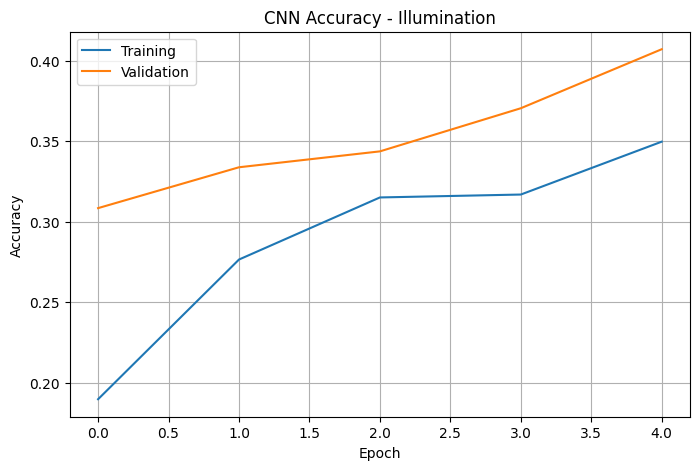

In [48]:
for dataset_name, history in cnn_histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(
        history.history["accuracy"],
        label="Training"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation"
    )

    plt.title(f"CNN Accuracy - {dataset_name}")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.show()

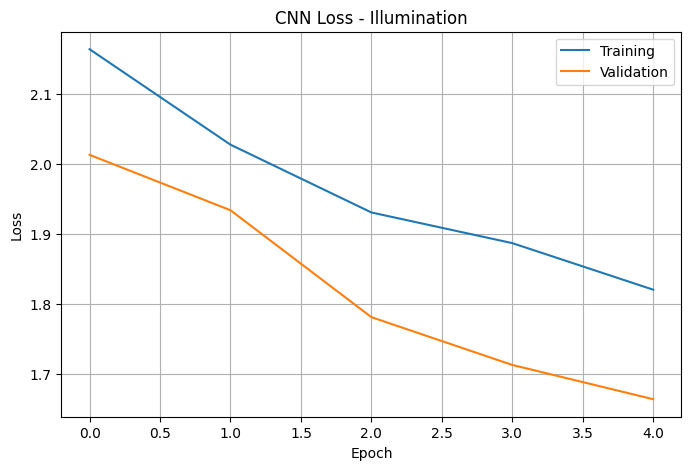

In [49]:
for dataset_name, history in cnn_histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(
        history.history["loss"],
        label="Training"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation"
    )

    plt.title(f"CNN Loss - {dataset_name}")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.show()

<Figure size 800x800 with 0 Axes>

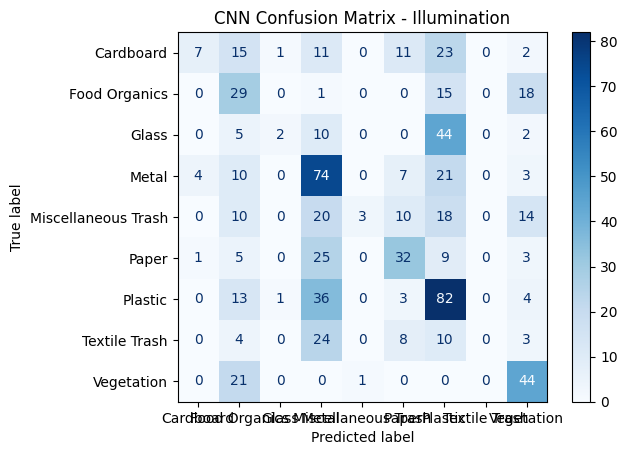

In [50]:
for dataset_name, cm in cnn_confusion_matrices.items():

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=list(
            test_generator.class_indices.keys()
        )

    )

    disp.plot(cmap="Blues")

    plt.title(f"CNN Confusion Matrix - {dataset_name}")

    plt.show()

In [51]:
print(cnn_results_df)

        Dataset Model  Accuracy  Precision    Recall  F1 Score
0  Illumination   CNN  0.379694   0.424308  0.379694  0.319719


In [52]:
# combining resutls

In [53]:
all_results = pd.concat(
    [
        results_df,
        ann_results_df,
        cnn_results_df
    ],
    ignore_index=True
)

all_results

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Original,SVM,0.728790,0.736046,0.728790,0.726962
1,Quality,SVM,0.696801,0.706073,0.696801,0.694825
2,Illumination,SVM,0.556328,0.561036,0.556328,0.548442
3,Original,ANN,0.759388,0.764817,0.759388,0.757857
4,Quality,ANN,0.703755,0.704288,0.703755,0.701630
5,Illumination,ANN,0.610570,0.610453,0.610570,0.607300
6,Illumination,CNN,0.379694,0.424308,0.379694,0.319719


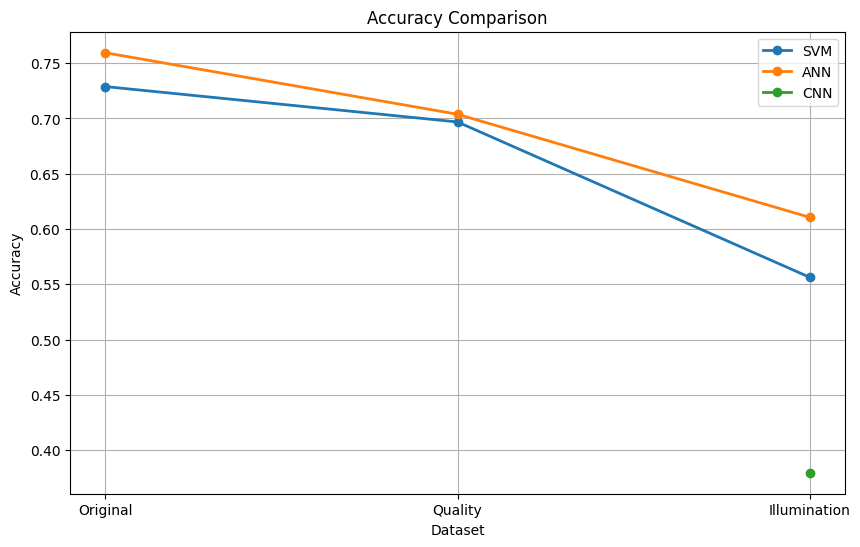

In [54]:
plt.figure(figsize=(10,6))

for model in all_results["Model"].unique():

    data = all_results[
        all_results["Model"] == model
    ]

    plt.plot(
        data["Dataset"],
        data["Accuracy"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Accuracy Comparison")

plt.xlabel("Dataset")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

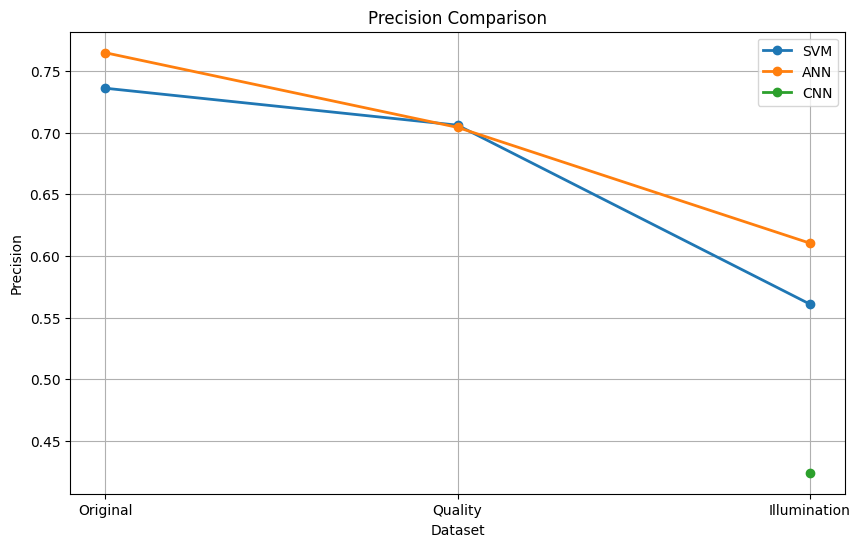

In [55]:
plt.figure(figsize=(10,6))

for model in all_results["Model"].unique():

    data = all_results[
        all_results["Model"] == model
    ]

    plt.plot(
        data["Dataset"],
        data["Precision"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Precision Comparison")

plt.xlabel("Dataset")

plt.ylabel("Precision")

plt.legend()

plt.grid(True)

plt.show()

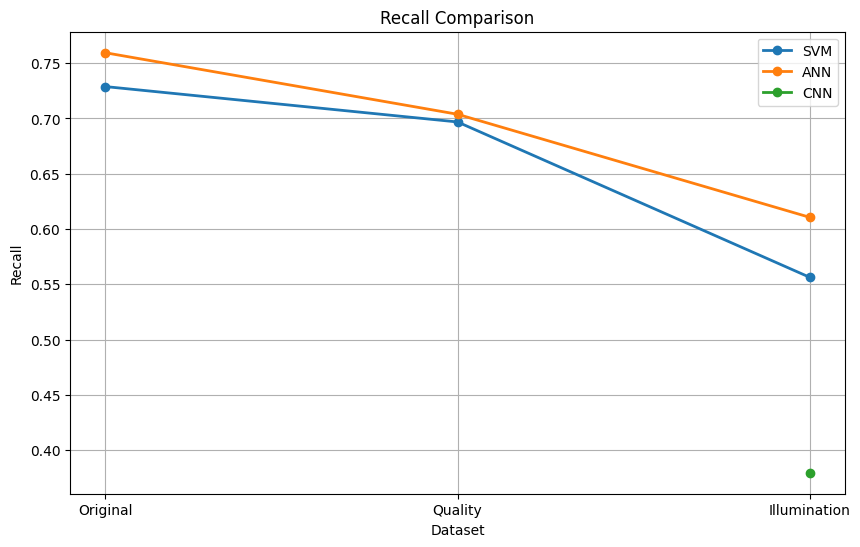

In [56]:
plt.figure(figsize=(10,6))

for model in all_results["Model"].unique():

    data = all_results[
        all_results["Model"] == model
    ]

    plt.plot(
        data["Dataset"],
        data["Recall"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Recall Comparison")

plt.xlabel("Dataset")

plt.ylabel("Recall")

plt.legend()

plt.grid(True)

plt.show()

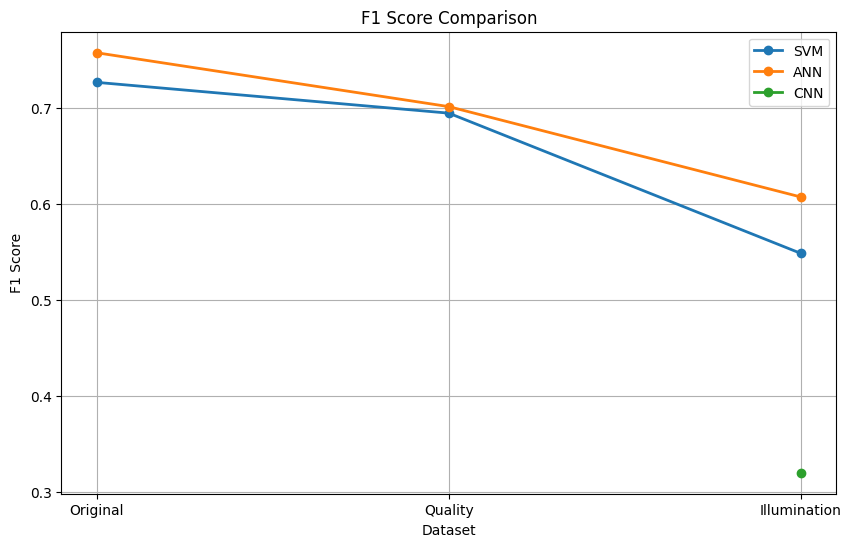

In [57]:
plt.figure(figsize=(10,6))

for model in all_results["Model"].unique():

    data = all_results[
        all_results["Model"] == model
    ]

    plt.plot(
        data["Dataset"],
        data["F1 Score"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("F1 Score Comparison")

plt.xlabel("Dataset")

plt.ylabel("F1 Score")

plt.legend()

plt.grid(True)

plt.show()

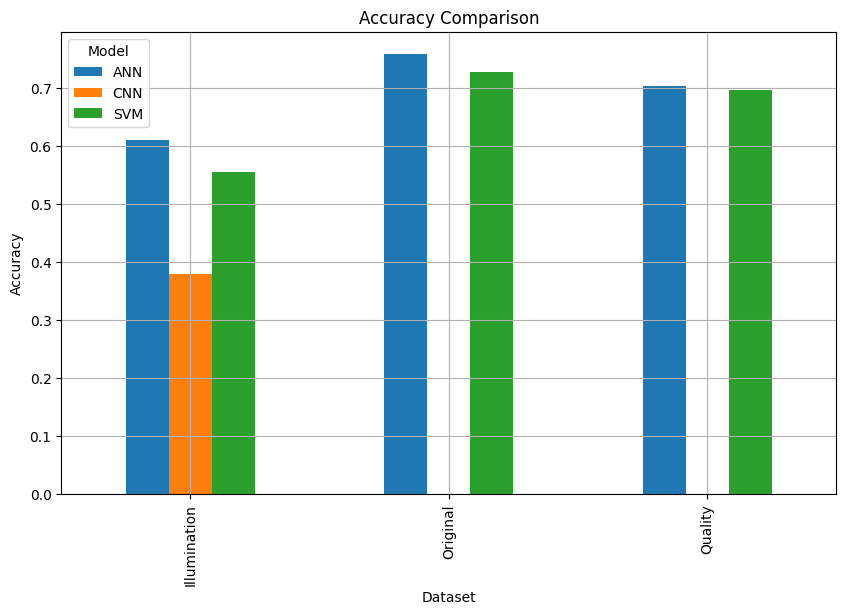

In [58]:
accuracy_table = all_results.pivot(
    index="Dataset",
    columns="Model",
    values="Accuracy"
)

accuracy_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

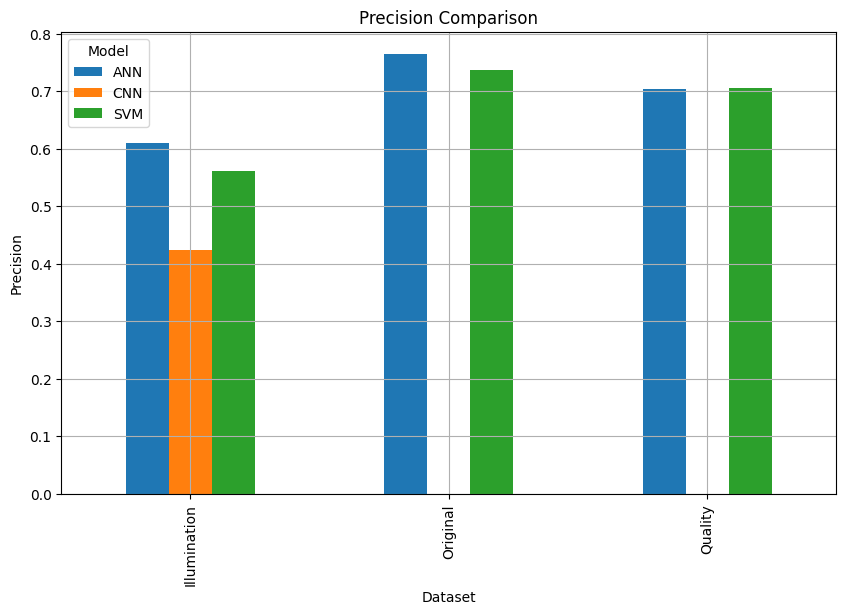

In [59]:
precision_table = all_results.pivot(
    index="Dataset",
    columns="Model",
    values="Precision"
)

precision_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision Comparison")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

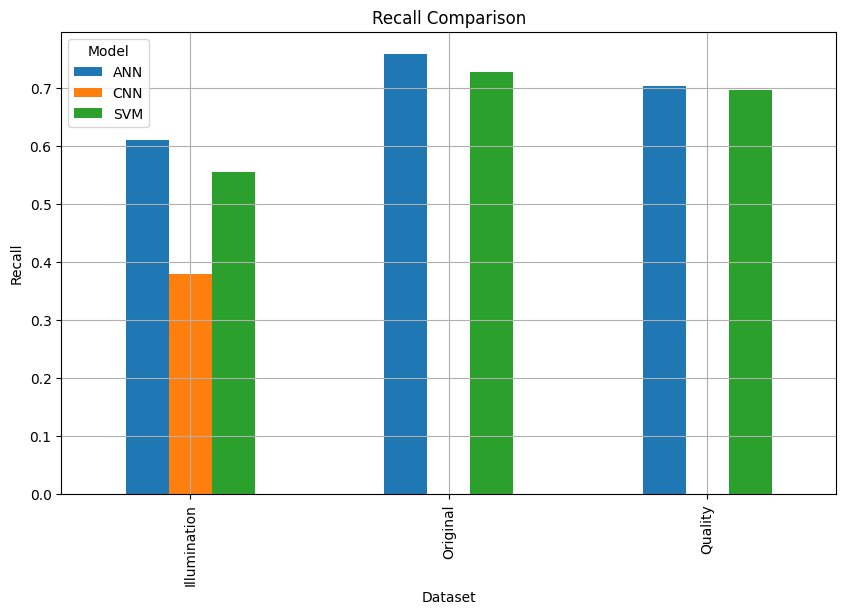

In [60]:
recall_table = all_results.pivot(
    index="Dataset",
    columns="Model",
    values="Recall"
)

recall_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Recall Comparison")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

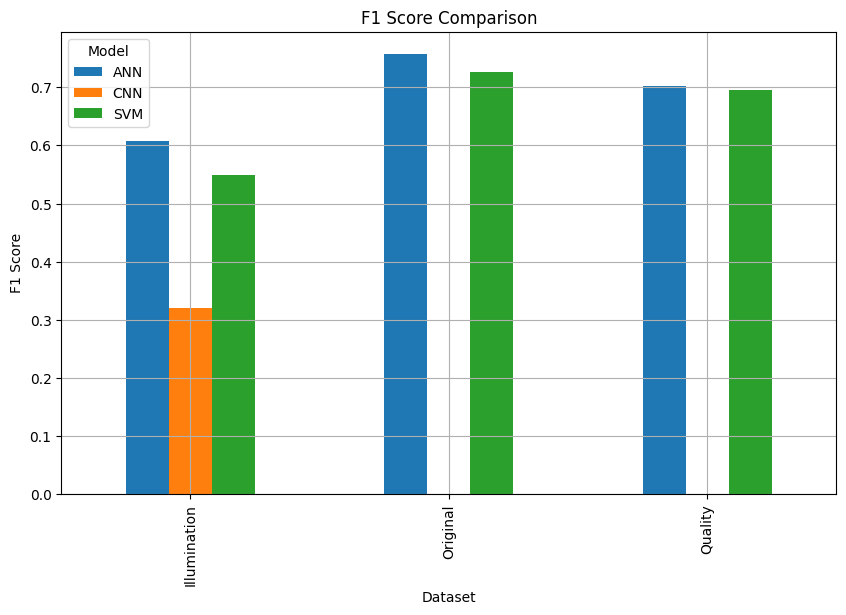

In [61]:
f1_table = all_results.pivot(
    index="Dataset",
    columns="Model",
    values="F1 Score"
)

f1_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

In [62]:
best_models = all_results.loc[
    all_results.groupby("Dataset")["Accuracy"].idxmax()
]

best_models

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
5,Illumination,ANN,0.610570,0.610453,0.610570,0.607300
3,Original,ANN,0.759388,0.764817,0.759388,0.757857
4,Quality,ANN,0.703755,0.704288,0.703755,0.701630


In [63]:
ranking = all_results.groupby("Model")[
    ["Accuracy","Precision","Recall","F1 Score"]
].mean()

ranking = ranking.sort_values(
    by="Accuracy",
    ascending=False
)

ranking

,Accuracy,Precision,Recall,F1 Score
Model,,,,
ANN,0.691238,0.693186,0.691238,0.688929
SVM,0.660640,0.667718,0.660640,0.656743
CNN,0.379694,0.424308,0.379694,0.319719
